<a href="https://colab.research.google.com/github/chaitanyatalakeri27-png/Data_Science_Lab/blob/main/Exp5_Conv_Nets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 218s 1us/step


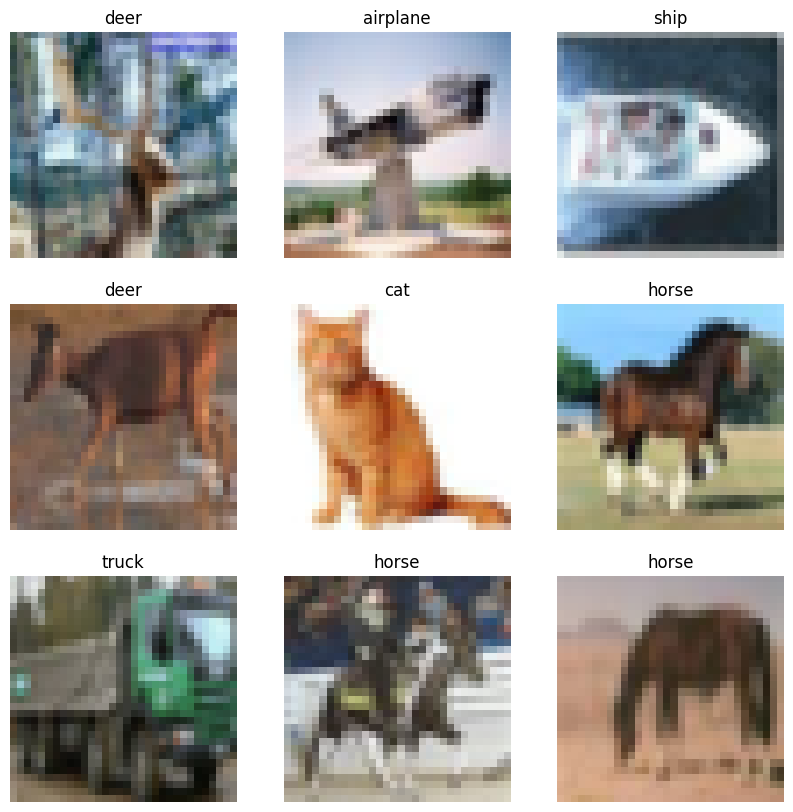

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 24)     │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 48)     │        10,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 48)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 48)             │         2,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,930 (54.41 KB)

 Trainable params: 13,930 (54.41 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.1210 - loss: 2.2892 - val_accuracy: 0.1540 - val_loss: 2.2547
Epoch 2/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.1800 - loss: 2.2133 - val_accuracy: 0.1960 - val_loss: 2.1816
Epoch 3/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.1975 - loss: 2.1351 - val_accuracy: 0.1480 - val_loss: 2.1941
Epoch 4/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.2090 - loss: 2.0862 - val_accuracy: 0.1900 - val_loss: 2.0719
Epoch 5/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.2307 - loss: 2.0481 - val_accuracy: 0.2120 - val_loss: 2.0602
Epoch 6/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - accuracy: 0.2420 - loss: 2.0133 - val_accuracy: 0.1630 - val_loss: 2.2003
Epoch 7/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.2460 - loss: 1.9987 - val_accuracy: 0.2170 - val_loss: 2.0566
Epoch 8/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.2540 - loss: 1.9656 - val_accuracy: 0.2170 - val_los

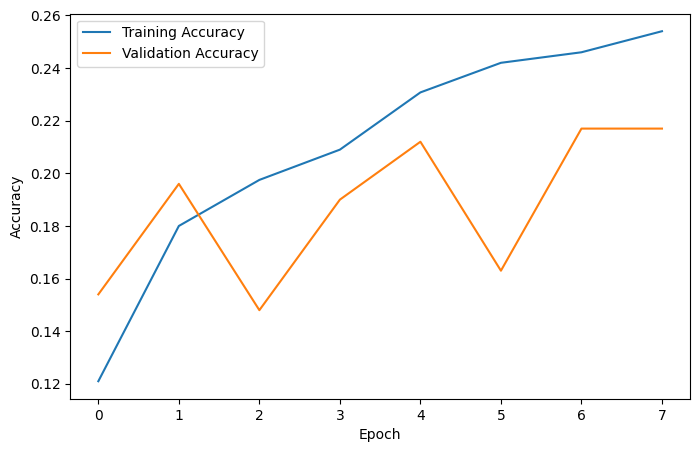

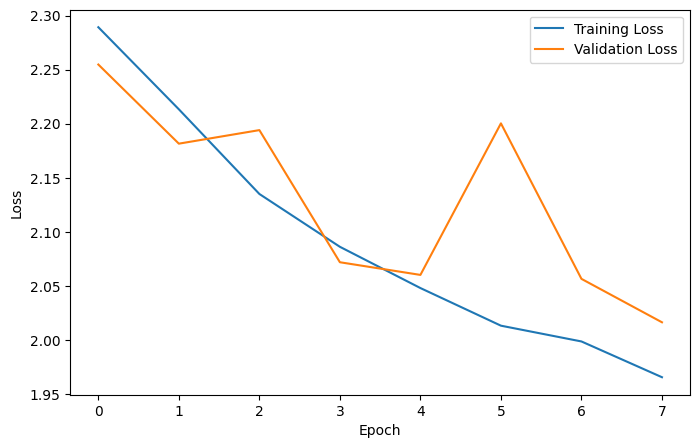

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# Load CIFAR-10 Dataset
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# OPTIMIZATION 1: Grab a completely different slice of the dataset
# Taking images 10,000 to 14,000 to ensure fresh data and fast training
X_train = X_train[10000:14000] / 255.0
y_train = y_train[10000:14000]
X_test = X_test[2000:3000] / 255.0
y_test = y_test[2000:3000]

# Class Names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Display Sample Images
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    # OPTIMIZATION 2: Change offset to 300 to show new visual outputs
    img_index = i + 300
    plt.imshow(X_train[img_index])
    plt.title(class_names[y_train[img_index][0]])
    plt.axis('off')

plt.show()

# Build CNN Model
model = models.Sequential()

# OPTIMIZATION 3: Completely different, lighter architecture
model.add(layers.Conv2D(
    24,
    (3,3),
    activation='relu',
    input_shape=(32,32,3)
))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(
    48,
    (3,3),
    activation='relu'
))
model.add(layers.MaxPooling2D((2,2)))

# OPTIMIZATION 4: Replaced Flatten with GlobalAveragePooling to slash parameter count
model.add(layers.GlobalAveragePooling2D())

# Lighter Dense Layers
model.add(layers.Dense(
    48,
    activation='relu'
))

model.add(layers.Dense(
    10,
    activation='softmax'
))

# Model Summary
model.summary()

# Compile Model - Swapped Adam for RMSprop to change learning behavior
model.compile(
    optimizer='rmsprop',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model - New batch size and epochs for different graphing results
history = model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=128,
    validation_data=(X_test, y_test)
)

# Evaluate Model
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("\nTest Accuracy :", test_accuracy)

# Plot Accuracy Graph
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Plot Loss Graph
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()